In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from PIL import Image
from sklearn.model_selection import train_test_split
import seaborn as sns


In [3]:
IMAGE_DIR = "/kaggle/input/datasets/alaamohsalahmotawe/harmonized-sentinel-landsat-water-dataset/data/images"
LABEL_DIR = "/kaggle/input/datasets/alaamohsalahmotawe/harmonized-sentinel-landsat-water-dataset/data/labels"

In [4]:
def load_data(image_dir, label_dir):
    images = []
    masks = []
    
    image_files = sorted(os.listdir(image_dir))
    
    for file in image_files:
        if file.endswith(".tif"):
            image_path = os.path.join(image_dir, file)
            label_path = os.path.join(label_dir, file.replace(".tif", ".png"))
            
            # Read multispectral image (12 bands)
            with rasterio.open(image_path) as src:
                image = src.read()  # (bands, H, W)
                image = np.transpose(image, (1, 2, 0))  # (H, W, bands)
            
            # Read mask
            mask = Image.open(label_path)
            mask = np.array(mask)
            
            # Ensure binary
            mask = (mask > 0).astype(np.float32)
            mask = np.expand_dims(mask, axis=-1)
            
            images.append(image)
            masks.append(mask)
    
    return np.array(images), np.array(masks)

In [5]:
X, y = load_data(IMAGE_DIR, LABEL_DIR)
print("Data shape:", X.shape, y.shape)

Data shape: (306, 128, 128, 12) (306, 128, 128, 1)


In [6]:
from sklearn.model_selection import train_test_split

test_ratio = 0.15

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=test_ratio,
    random_state=42,
    shuffle=True
)


val_ratio = 0.2

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_ratio,
    random_state=42,
    shuffle=True
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (208, 128, 128, 12)
Validation: (52, 128, 128, 12)
Test: (46, 128, 128, 12)


In [7]:
# Standardization (Z-score) based on training data

means = X_train.mean(axis=(0,1,2))
stds  = X_train.std(axis=(0,1,2))

def normalize(X, means, stds):
    return (X - means) / (stds + 1e-8)

# Apply normalization
X_train = normalize(X_train, means, stds)
X_val   = normalize(X_val, means, stds)
X_test  = normalize(X_test, means, stds)

print("After Z-score normalization:")
print("Min:", X_train.min(), "Max:", X_train.max())
print("Mean per band:", X_train.mean(axis=(0,1,2)))

After Z-score normalization:
Min: -7.171619697080086 Max: 28.84644096647968
Mean per band: [-2.39832153e-15  1.50806430e-16 -1.88958521e-16 -3.71903045e-15
  5.46801622e-16  1.50199590e-15  1.60353641e-15  1.55983313e-13
  2.46247078e-13 -6.33692179e-14  2.51924557e-13  1.15591329e-13]


In [10]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:0000:01


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp


In [12]:
from torch.utils.data import Dataset, DataLoader

class WaterDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0,3,1,2)

        y = np.squeeze(y)  # إزالة البعد الزائد
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = WaterDataset(X_train, y_train)
val_dataset   = WaterDataset(X_val, y_val)
test_dataset  = WaterDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8)
test_loader  = DataLoader(test_dataset, batch_size=8)

In [13]:
images, masks = next(iter(train_loader))
print(images.shape) 
print(masks.shape)  

torch.Size([8, 12, 128, 128])
torch.Size([8, 1, 128, 128])


In [15]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()

        dice = (2*intersection + self.smooth) / (
            preds.sum() + targets.sum() + self.smooth
        )

        return 1 - dice


bce = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def combined_loss(pred, target):
    return bce(pred, target) + dice_loss(pred, target)



def get_metrics(preds, targets, threshold=0.5):

    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    tp = (preds * targets).sum()
    fp = (preds * (1 - targets)).sum()
    fn = ((1 - preds) * targets).sum()

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)

    iou = tp / (tp + fp + fn + 1e-6)
    dice = (2*tp) / (2*tp + fp + fn + 1e-6)

    f1 = dice   

    return (
        precision.item(),
        recall.item(),
        iou.item(),
        dice.item(),
        f1.item()
    )

In [17]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cuda


In [18]:
model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=12,
    classes=1,
).to(DEVICE)

In [19]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [20]:
train_losses = []
val_losses = []

train_ious = []
val_ious = []

train_dices = []
val_dices = [] 

best_iou = 0


In [22]:
EPOCHS =30
for epoch in range(EPOCHS):

    # ===========TRAIN================
    model.train()

    train_loss = 0
    train_iou = 0
    train_dice = 0
    
    for images, masks in train_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, _, iou, dice, _ = get_metrics(outputs, masks)
        train_iou += iou
        train_dice += dice
    
    train_loss /= len(train_loader)
    train_iou /= len(train_loader)
    train_dice /= len(train_loader)
    
    train_losses.append(train_loss)
    train_ious.append(train_iou)
    train_dices.append(train_dice)
    
    
    # ================= VALIDATION =================
    model.eval()

    val_loss = 0
    val_iou = 0
    val_dice = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)

            loss = combined_loss(outputs, masks)
            val_loss += loss.item()

            _, _, iou,dice, _ = get_metrics(outputs, masks)
            val_iou += iou
            val_dice += dice
            
    val_loss /= len(val_loader)
    val_iou /= len(val_loader)
    val_dice /= len(val_loader)
    val_dices.append(val_dice)

    val_losses.append(val_loss)
    val_ious.append(val_iou)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train IoU: {train_iou:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val IoU: {val_iou:.4f}")
    print("-"*40)

    # Save best model
    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(),
                   "/kaggle/working/model.pth")

Epoch 1
Train Loss: 1.2548
Train IoU: 0.3381
Val Loss: 1.2229
Val IoU: 0.3384
----------------------------------------
Epoch 2
Train Loss: 1.0464
Train IoU: 0.4467
Val Loss: 1.0083
Val IoU: 0.5134
----------------------------------------
Epoch 3
Train Loss: 0.9817
Train IoU: 0.4967
Val Loss: 0.8919
Val IoU: 0.5652
----------------------------------------
Epoch 4
Train Loss: 0.8141
Train IoU: 0.6003
Val Loss: 0.7849
Val IoU: 0.5819
----------------------------------------
Epoch 5
Train Loss: 0.7047
Train IoU: 0.6516
Val Loss: 0.6917
Val IoU: 0.6239
----------------------------------------
Epoch 6
Train Loss: 0.6375
Train IoU: 0.6891
Val Loss: 0.6396
Val IoU: 0.6460
----------------------------------------
Epoch 7
Train Loss: 0.6096
Train IoU: 0.6803
Val Loss: 0.5826
Val IoU: 0.6617
----------------------------------------
Epoch 8
Train Loss: 0.5750
Train IoU: 0.6970
Val Loss: 0.5319
Val IoU: 0.6860
----------------------------------------
Epoch 9
Train Loss: 0.5045
Train IoU: 0.7387
Val

In [23]:
model.eval()

all_precision = 0
all_recall = 0
all_iou = 0
all_dice = 0
all_f1 = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)

        precision, recall, iou, dice, f1 = get_metrics(outputs, masks)

        all_precision += precision
        all_recall += recall
        all_iou += iou
        all_dice += dice
        all_f1 += f1

n = len(test_loader)

print("\nTest Results")
print("Precision:", all_precision/n)
print("Recall:", all_recall/n)
print("IoU:", all_iou/n)
print("Dice:", all_dice/n)
print("F1-score:", all_f1/n)


Test Results
Precision: 0.90619428952535
Recall: 0.9108456571896871
IoU: 0.8342476387818655
Dice: 0.9084138174851736
F1-score: 0.9084138174851736


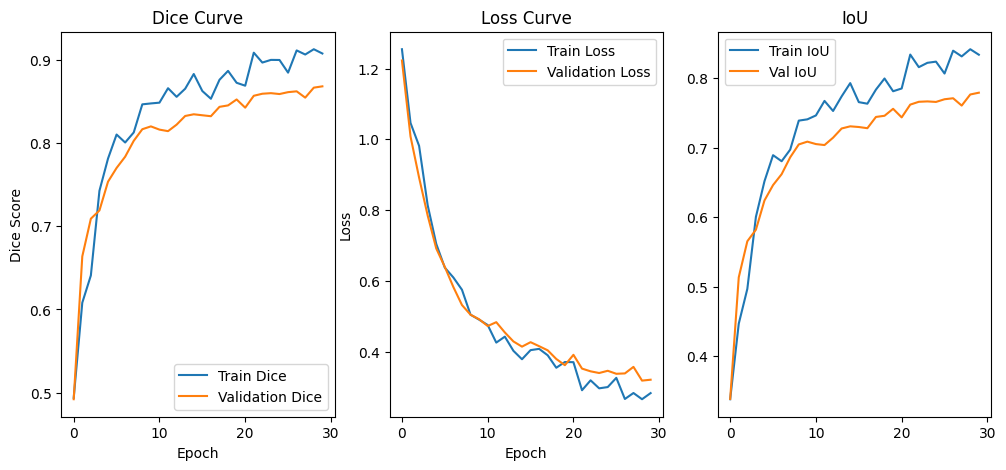

In [32]:
plt.figure(figsize=(12,5))



plt.subplot(1,3,1)
plt.plot(train_dices, label="Train Dice")
plt.plot(val_dices, label="Validation Dice")
plt.title("Dice Curve")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()

plt.subplot(1,3,2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,3,3)
plt.plot(train_ious, label="Train IoU")
plt.plot(val_ious, label="Val IoU")
plt.title("IoU")
plt.legend()

plt.show()

In [34]:
def show_all_test_predictions(model, dataset, threshold=0.5):

    model.eval()

    n_samples = len(dataset)

    for index in range(n_samples):

        image, true_mask = dataset[index]

        with torch.no_grad():
            image_input = image.unsqueeze(0).to(DEVICE)

            output = model(image_input)
            pred_mask = torch.sigmoid(output)
            pred_mask = (pred_mask > threshold).float()

        true_mask = true_mask.squeeze().cpu().numpy()
        pred_mask = pred_mask.squeeze().cpu().numpy()

        plt.figure(figsize=(12,4))

        plt.subplot(1,2,1)
        plt.imshow(true_mask, cmap='gray')
        plt.title("True Mask")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Predicted Mask")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

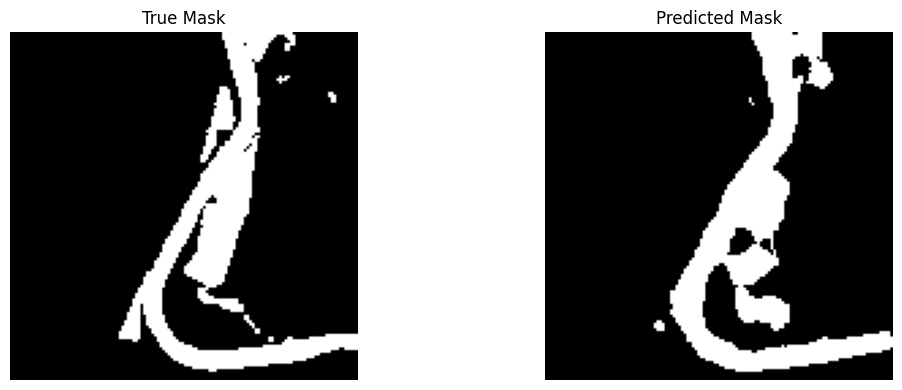

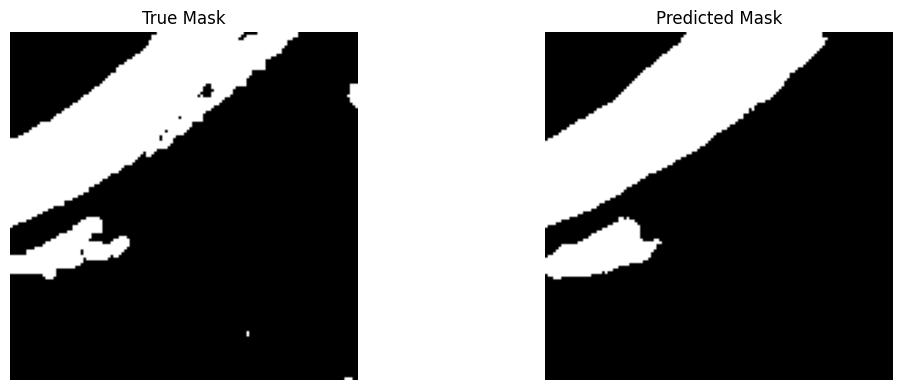

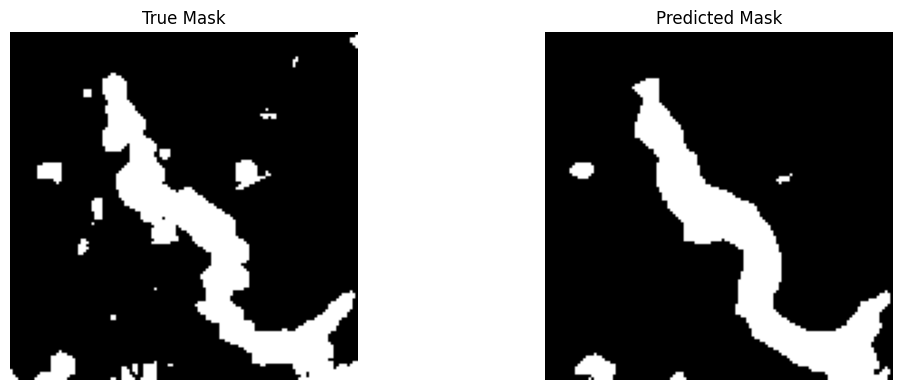

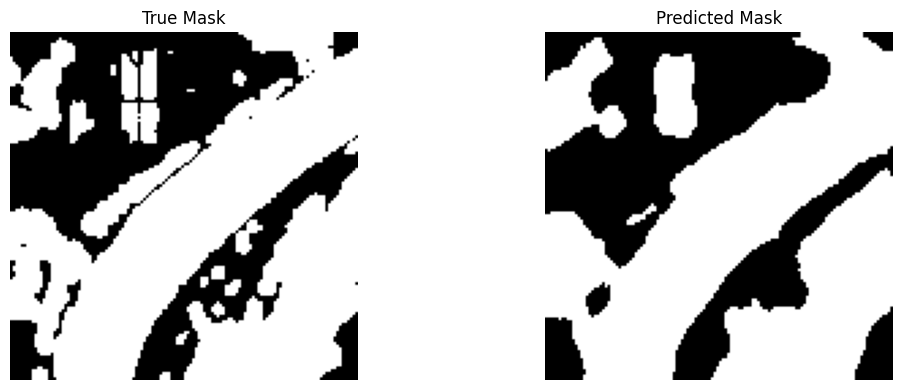

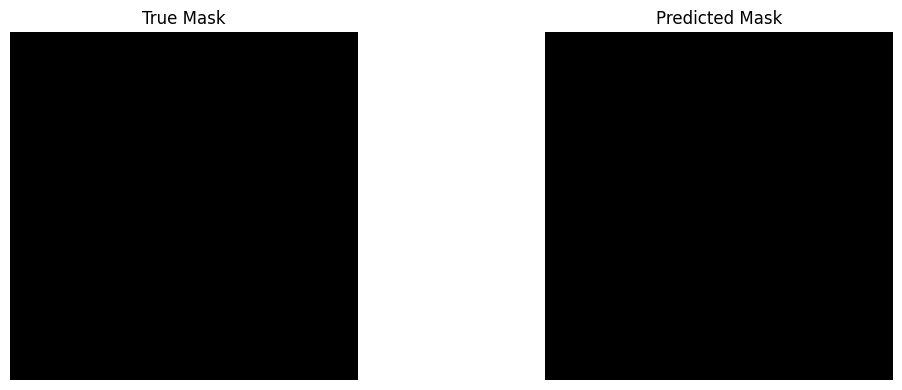

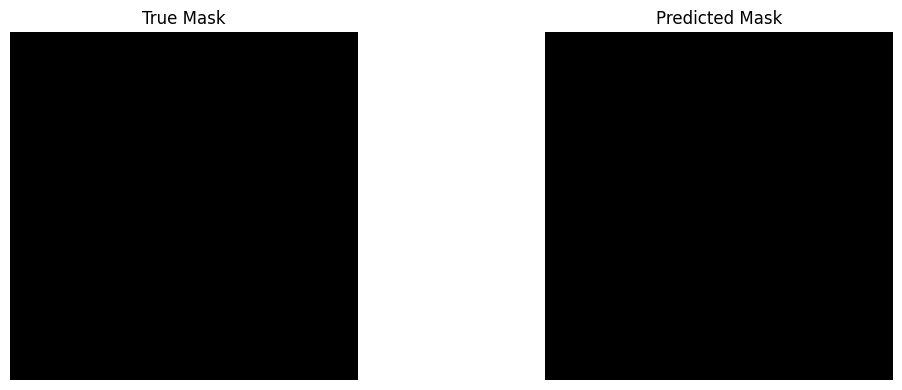

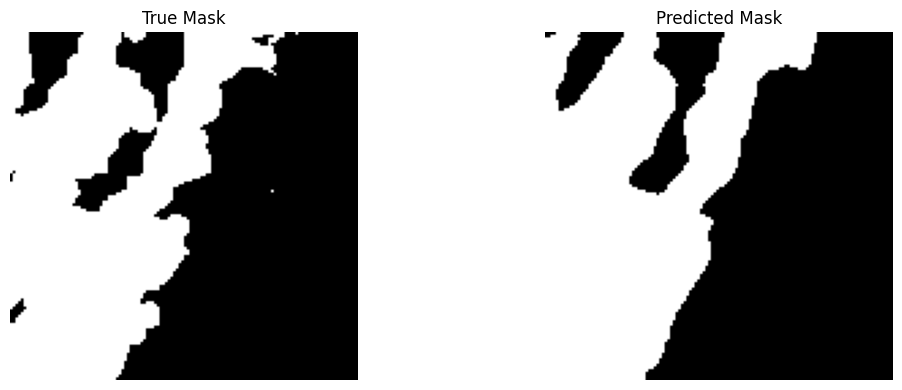

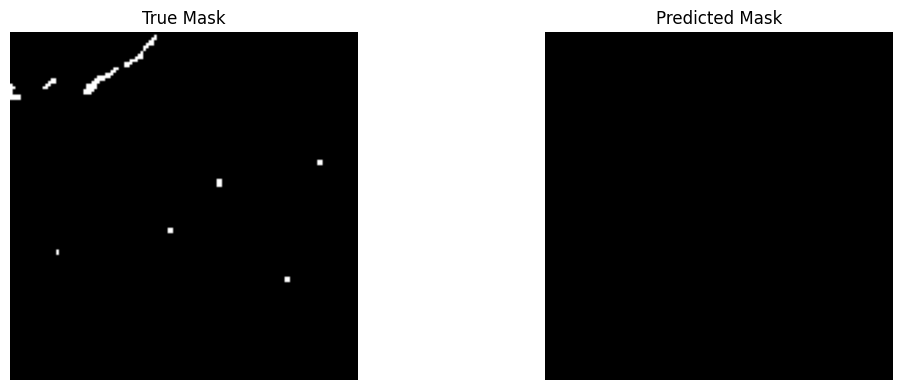

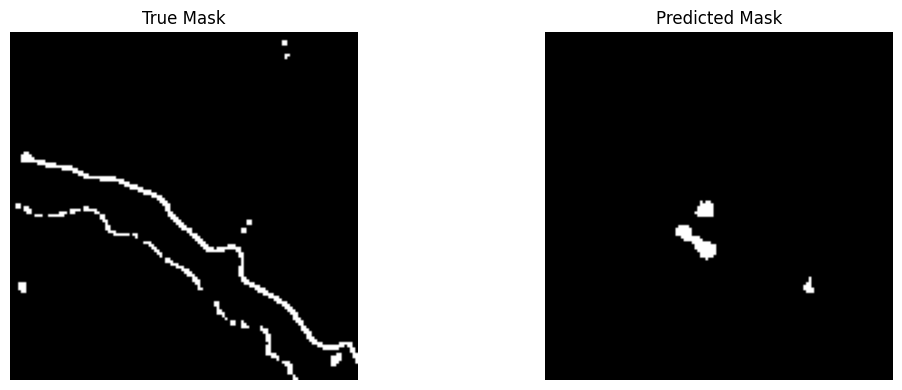

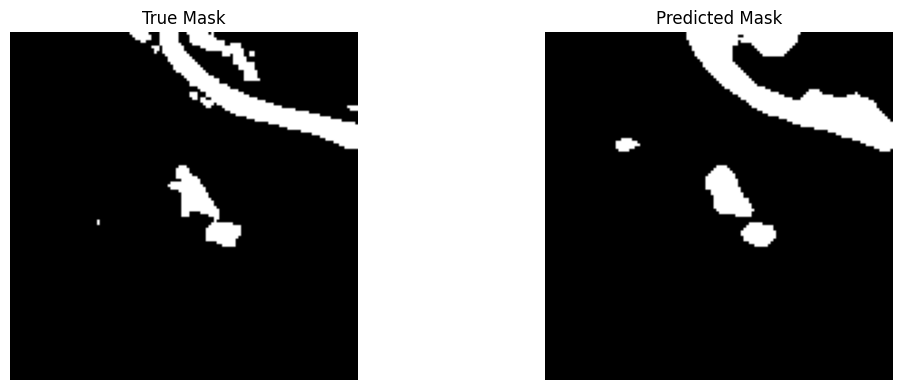

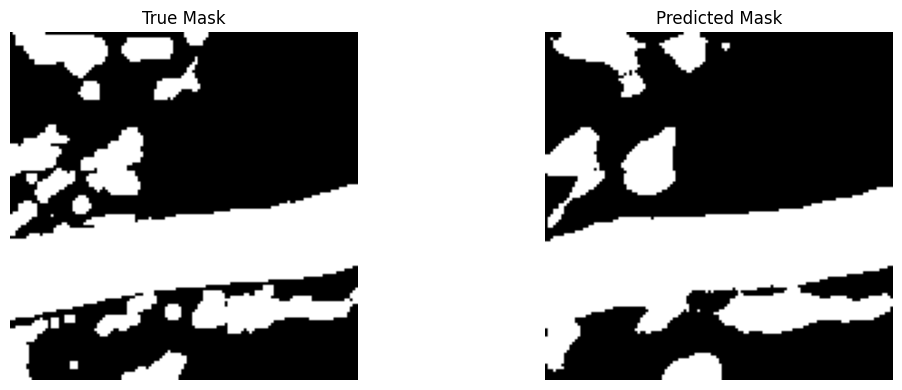

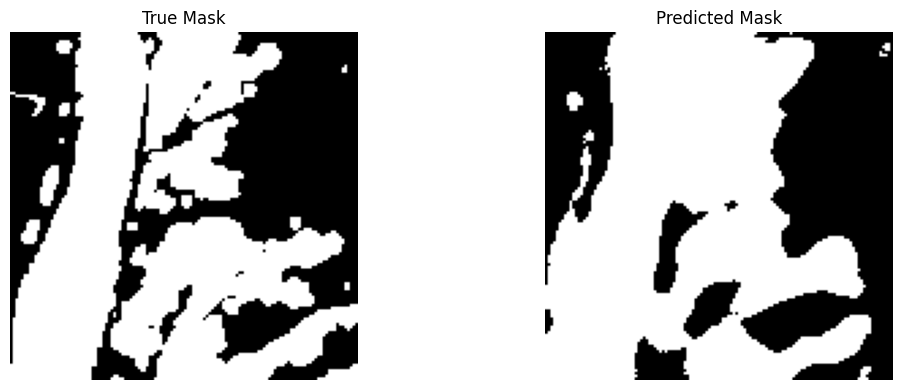

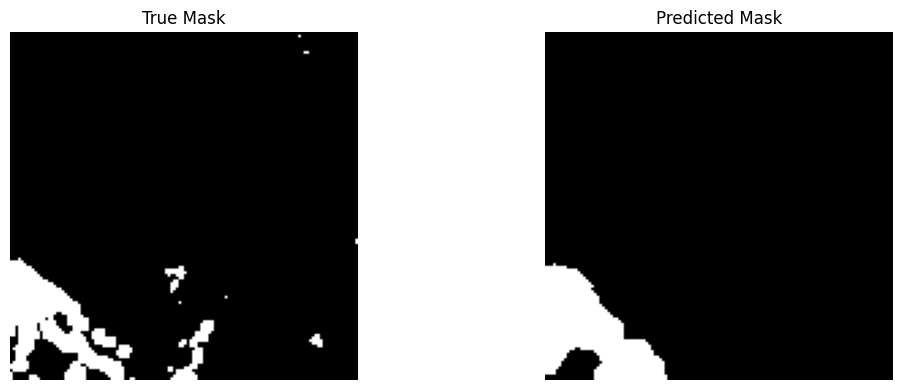

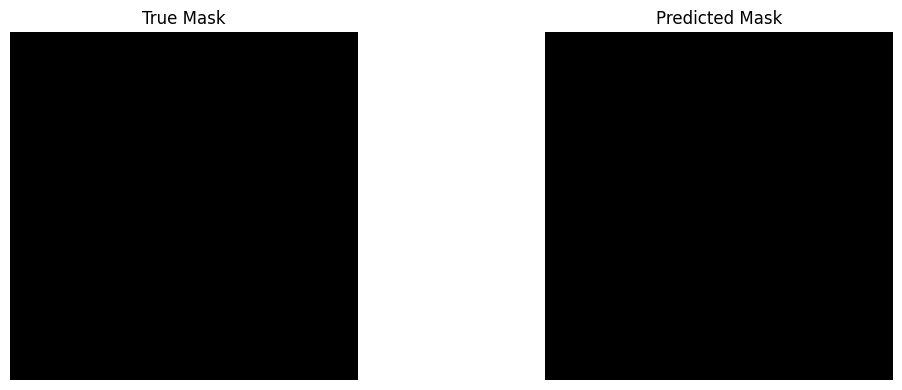

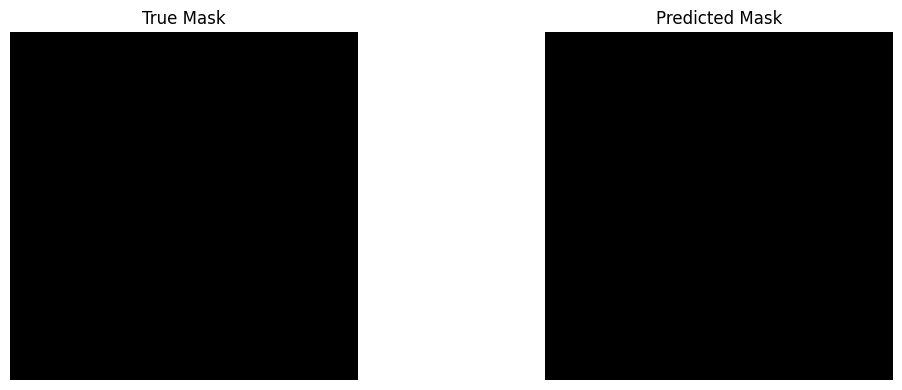

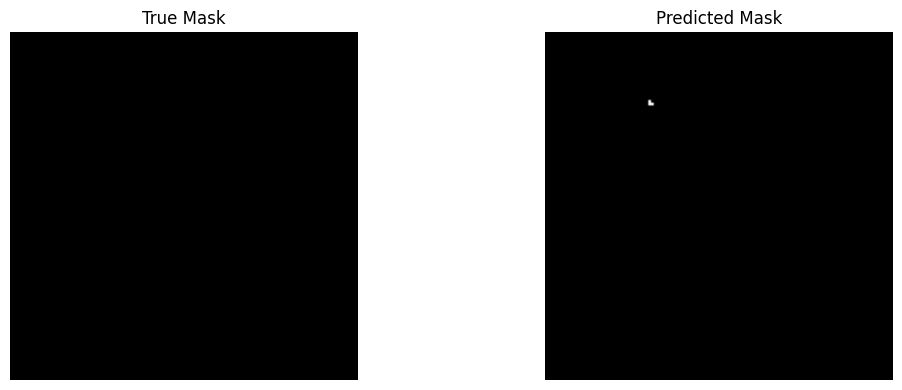

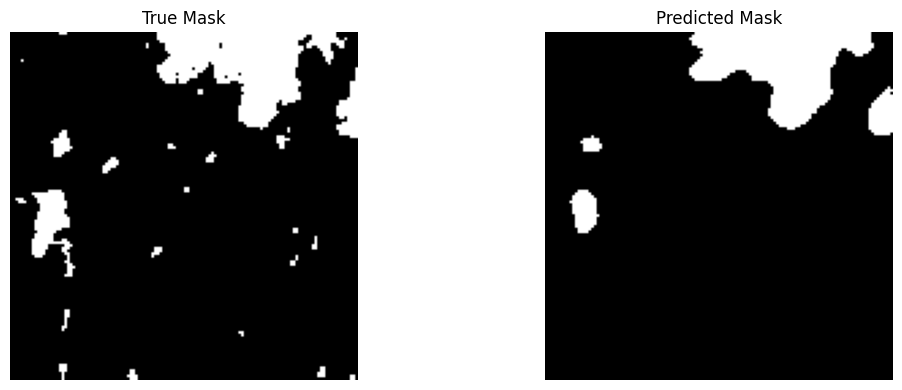

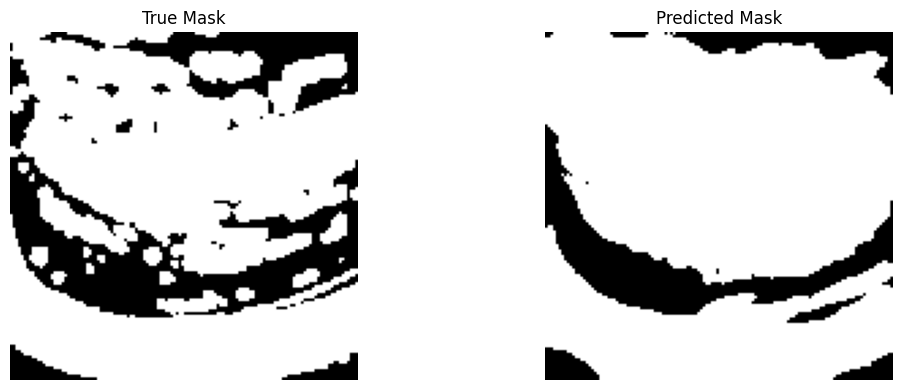

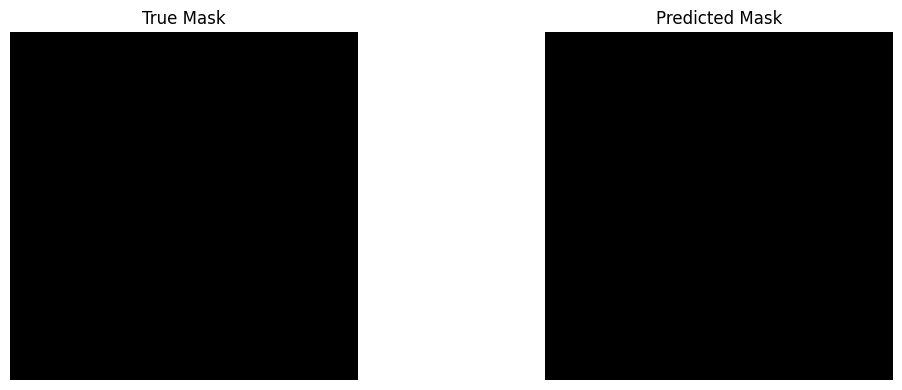

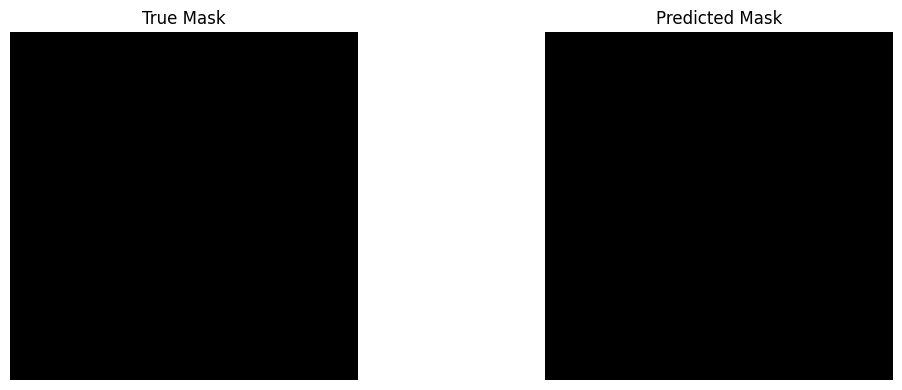

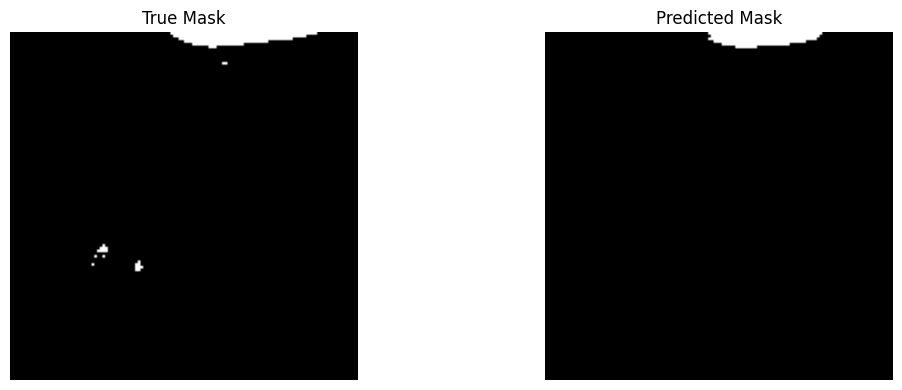

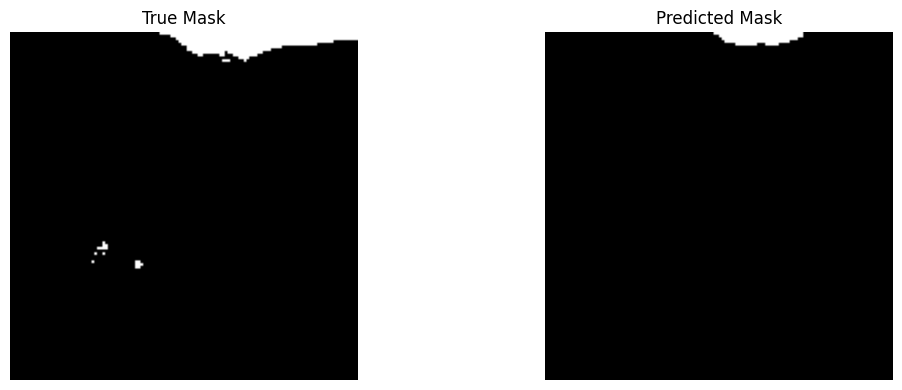

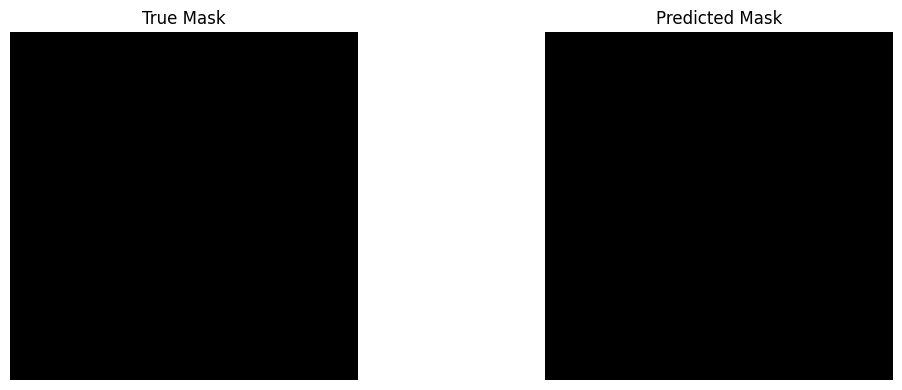

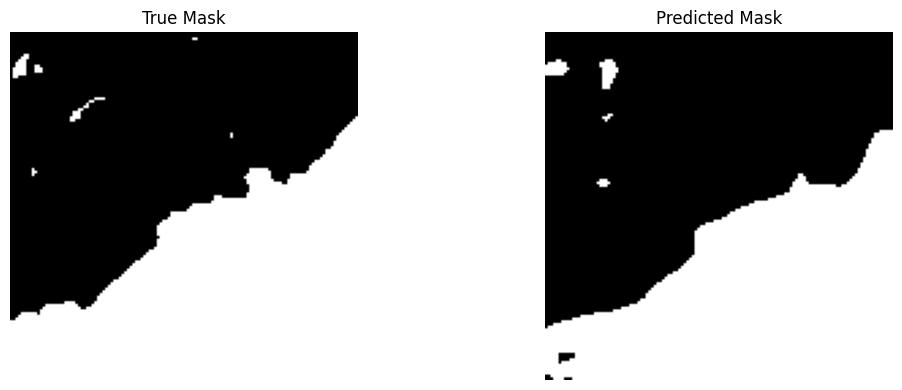

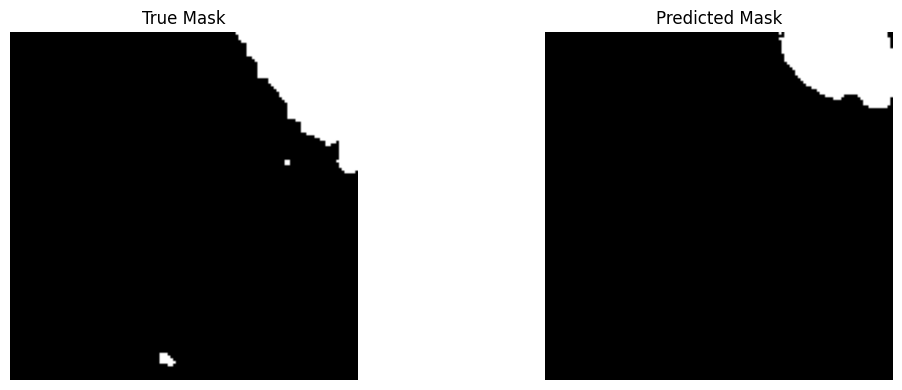

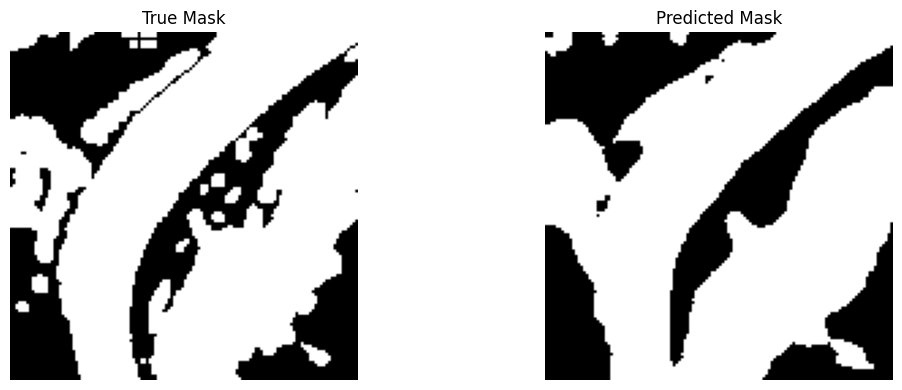

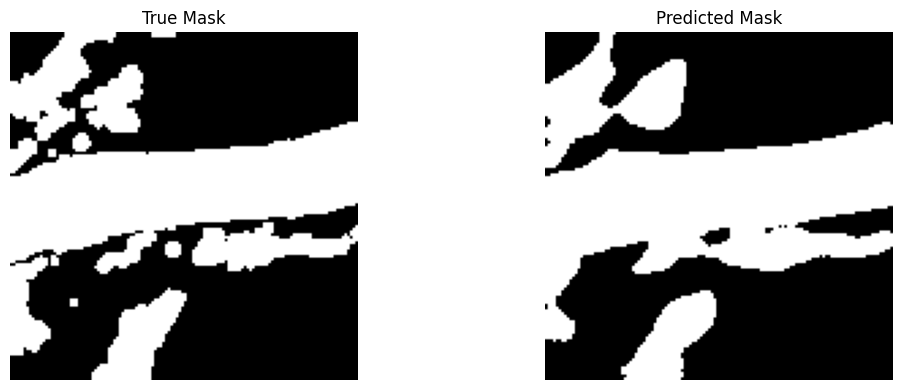

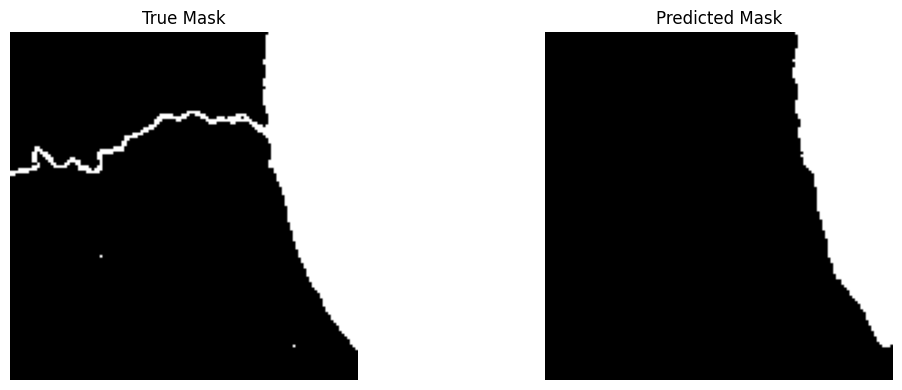

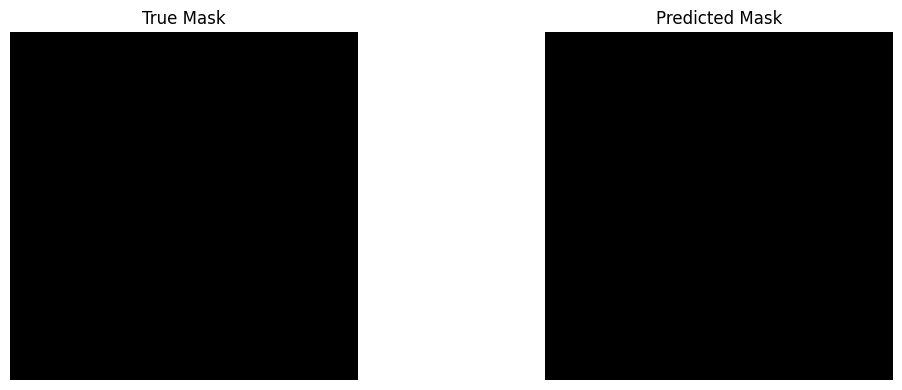

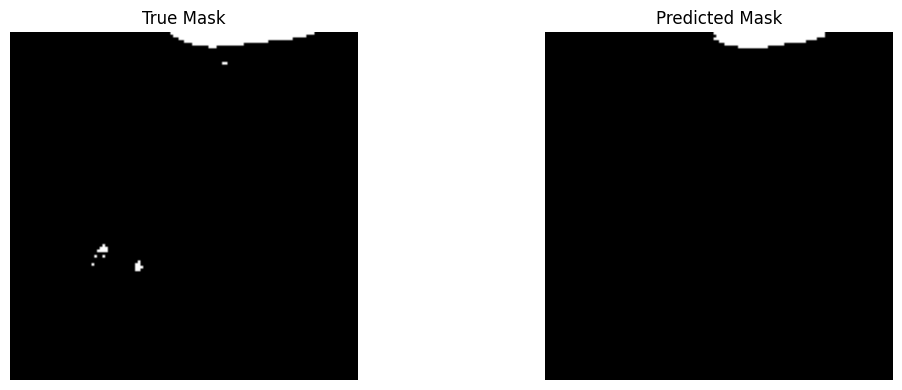

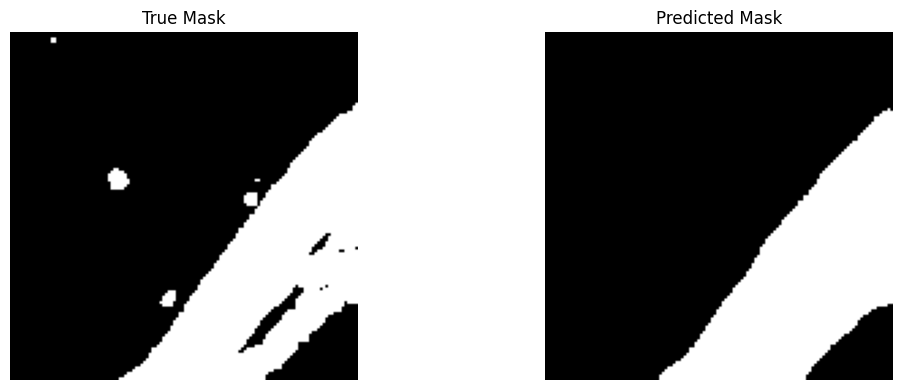

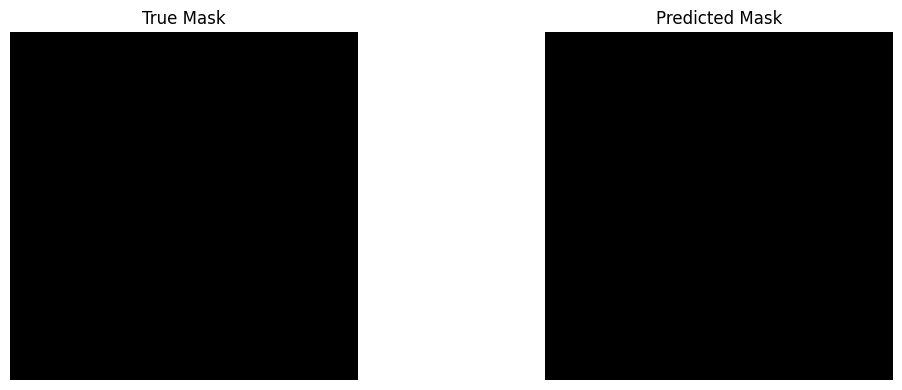

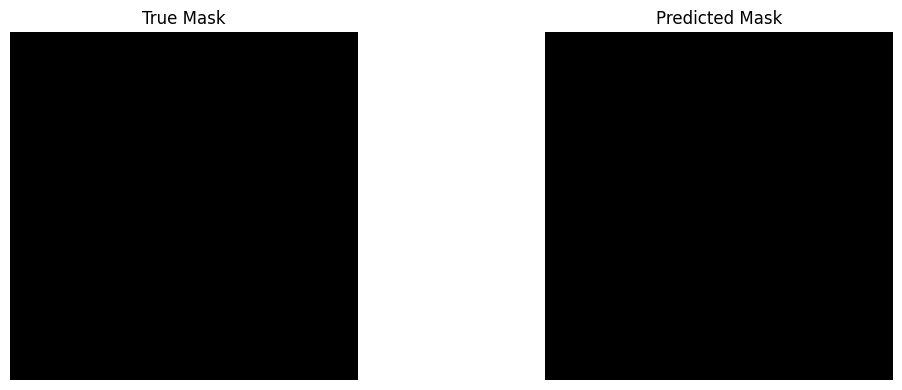

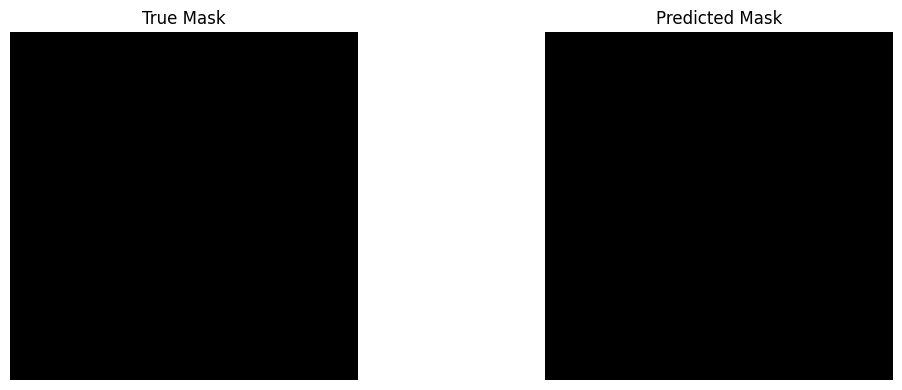

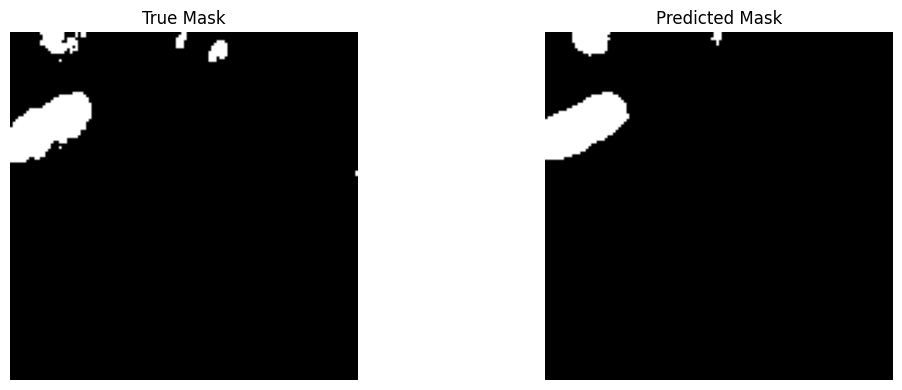

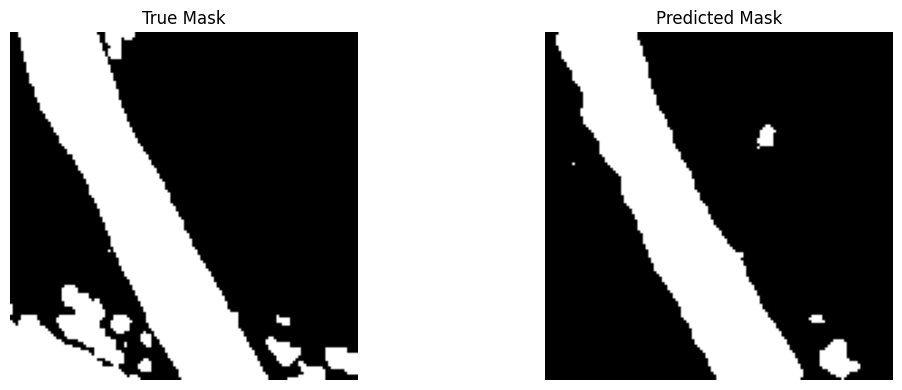

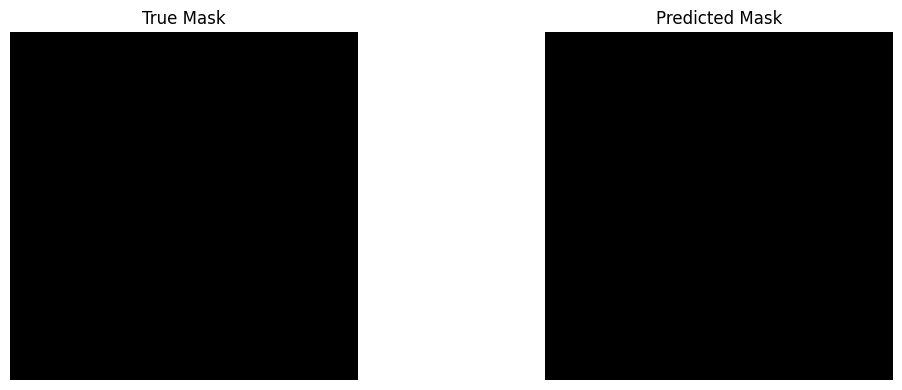

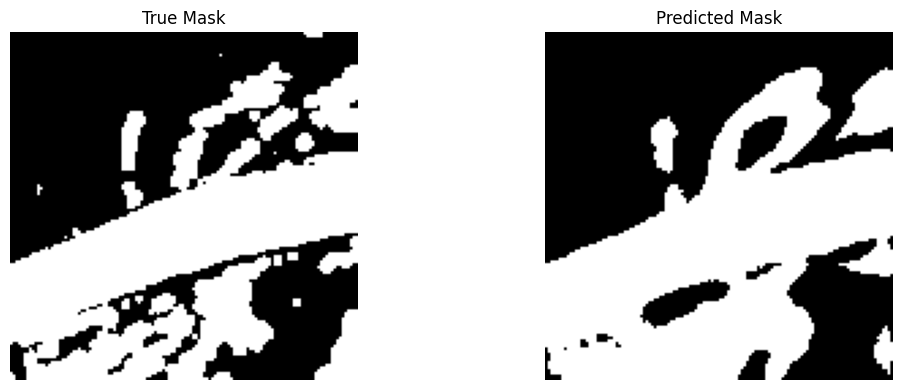

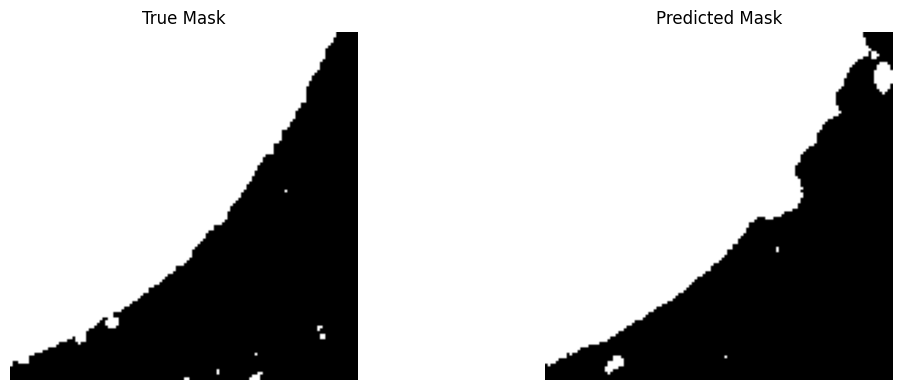

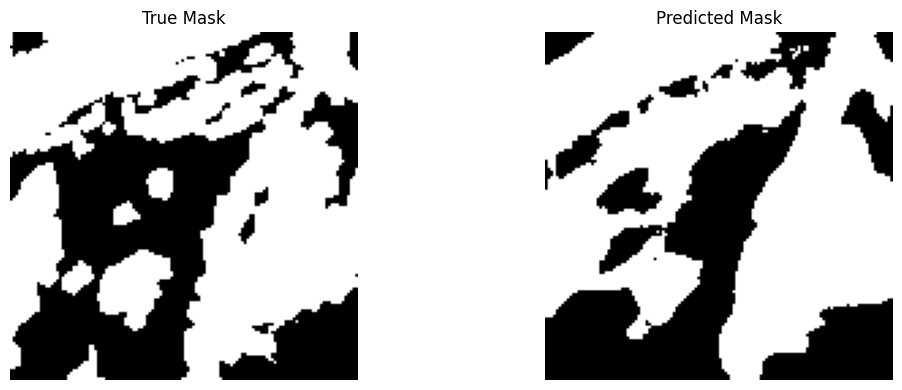

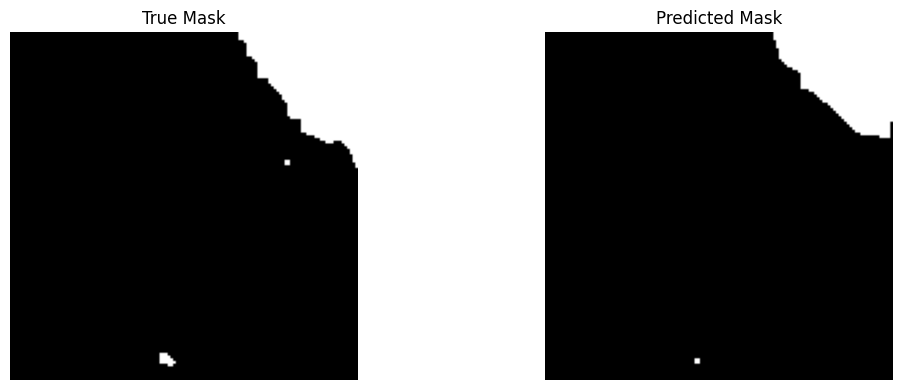

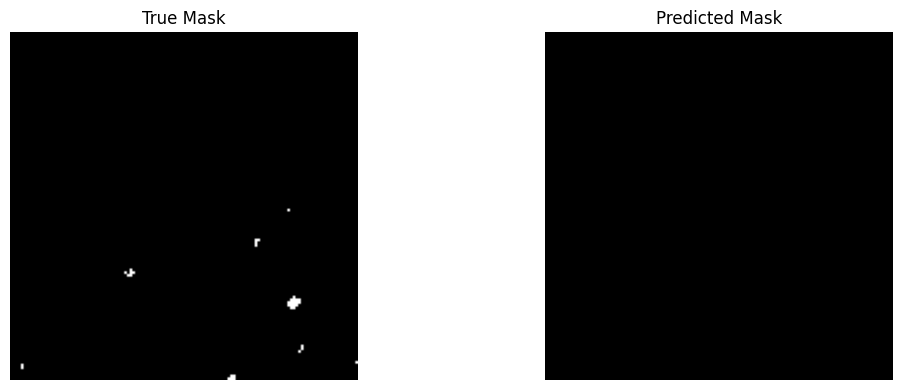

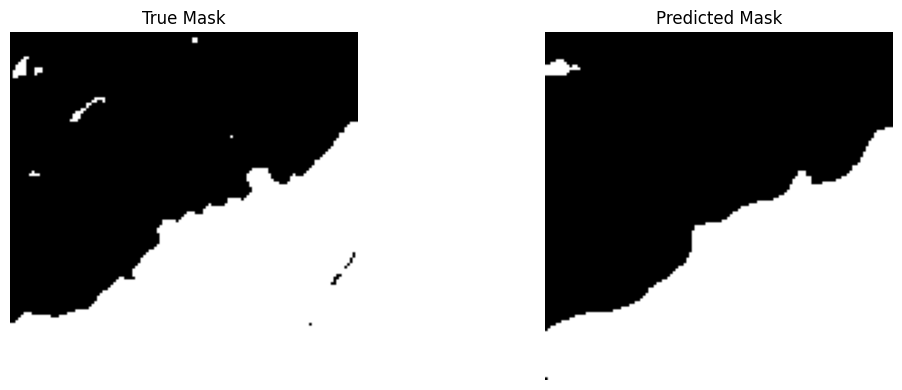

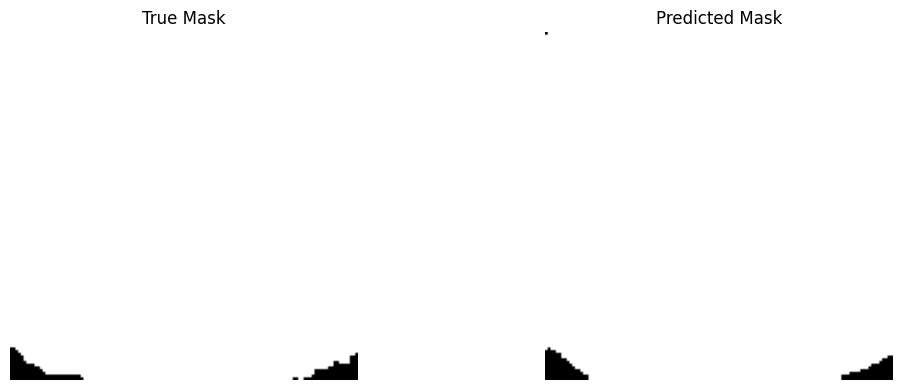

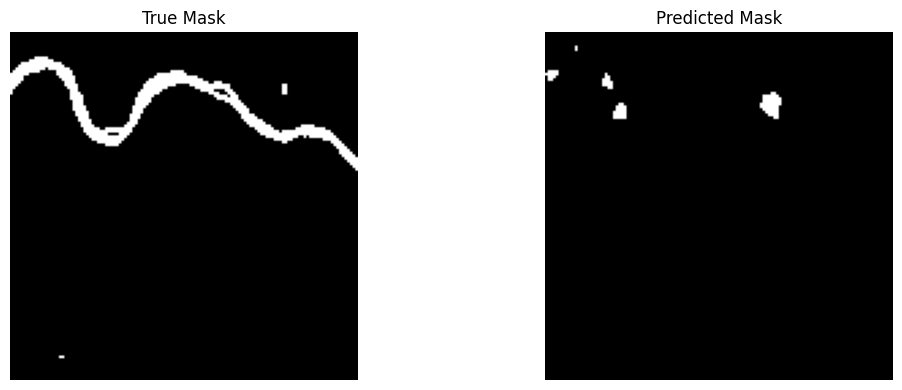

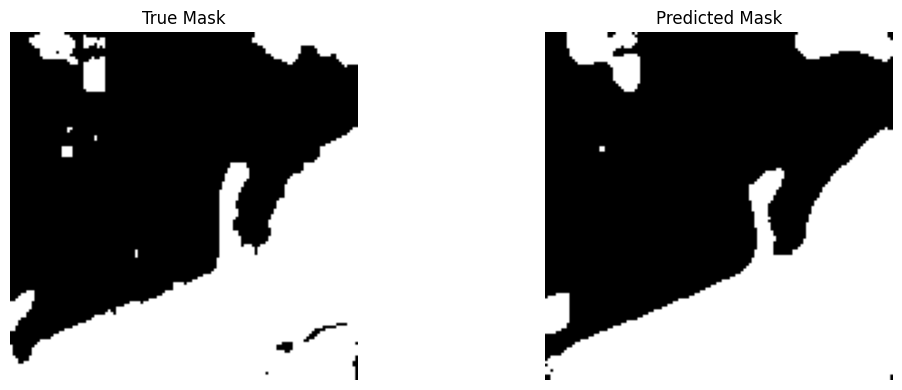

In [35]:
show_all_test_predictions(model, test_dataset)